# Mould-risk diagnostic notebook v2.0 — Fan intervention analysis

**Research question:** Did introducing a circulation fan (from **2026-05-11**) speed up recovery from high-humidity / condensation-risk conditions?

**Natural-experiment design.** Window-opening and dehumidifier use were unchanged across the whole period; the fan is the only deliberately introduced variable from 11 May. Before that date the fan did not exist (no socket data). So *Before (No Fan)* vs *After (Fan)* isolates the fan's effect — **provided** the ambient conditions did not also shift. Section 2 tests that assumption explicitly.

**Three measurements:**
1. Confound check — are temperature / ambient humidity comparable before vs after?
2. Time to escape the condensation-risk band (dewpoint spread ≤ 3 °C).
3. Descent time from a humidity peak (≥ 90%) down to 80 / 70 / 60% RH thresholds.

> Single-flat data: this is descriptive, not causal proof. n is reported on every comparison. This is multivariate descriptive statistics, not ML — dimensionality of one flat does not support classification.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda v: f'{v:.2f}')
plt.rcParams['figure.dpi'] = 110

SPLIT = pd.Timestamp('2026-05-11', tz='Europe/London')  # fan introduced

def period(t):
    return 'Before (No Fan)' if t < SPLIT else 'After (Fan)'

## 1. Load & prepare

Source timestamps carry `+0100` (BST). Parse as UTC then convert to `Europe/London` so the split boundary and any hour-of-day logic stay correct. (A common pitfall is `tz_localize(None)` after a naive parse, which silently shifts everything by an hour.)

In [22]:
df = pd.read_csv('../data/raw/humid_temp_sensor.csv')
df['ts'] = pd.to_datetime(df['received_at'], utc=True).dt.tz_convert('Europe/London')
df = df.sort_values('ts').reset_index(drop=True)

# Magnus formula -> dewpoint, then dewpoint spread (T - Td).
# Spread is a better condensation proxy than RH alone: it accounts for temperature.
L, B = 17.625, 243.04
alpha = ((L * df['temperature']) / (B + df['temperature'])) + np.log(df['humidity'] / 100.0)
df['dewpoint'] = (B * alpha) / (L - alpha)
df['spread']   = df['temperature'] - df['dewpoint']
df['Period']   = df['ts'].apply(period)

print(f"Rows: {len(df)}")
print(f"Range: {df['ts'].min()} -> {df['ts'].max()}")
df[['ts','temperature','humidity','dewpoint','spread','Period']].head()

Rows: 30087
Range: 2026-04-05 02:44:19.872000+01:00 -> 2026-05-31 15:03:55.242000+01:00


,ts,temperature,humidity,dewpoint,spread,Period
0,2026-04-05 02:44:19.872000+01:00,22.80,45.30,10.35,12.45,Before (No Fan)
1,2026-04-05 02:49:41.817000+01:00,22.80,48.10,11.25,11.55,Before (No Fan)
2,2026-04-05 02:49:51.752000+01:00,22.80,53.60,12.89,9.91,Before (No Fan)
3,2026-04-05 02:50:01.740000+01:00,22.80,53.30,12.81,9.99,Before (No Fan)
4,2026-04-05 02:50:11.725000+01:00,22.80,47.70,11.12,11.68,Before (No Fan)


## 2. Confound check — is the natural experiment valid?

If *Before* and *After* differ in temperature or ambient humidity, any recovery-speed difference could be seasonal drift rather than the fan. Here we want the two periods to look similar — and note the direction of any difference.

In [23]:
pre  = df[df['ts'] <  SPLIT]
post = df[df['ts'] >= SPLIT]

summary = pd.DataFrame({
    'Before (No Fan)': [pre['temperature'].mean(), pre['humidity'].mean(),
                        pre['spread'].mean(), pre[pre['humidity']<60]['humidity'].median(),
                        (pre['ts'].max()-pre['ts'].min()).days, len(pre)],
    'After (Fan)':     [post['temperature'].mean(), post['humidity'].mean(),
                        post['spread'].mean(), post[post['humidity']<60]['humidity'].median(),
                        (post['ts'].max()-post['ts'].min()).days, len(post)],
}, index=['mean temp °C','mean RH %','mean spread °C',
          'baseline RH % (median of <60% readings)','days span','n readings'])
summary

,Before (No Fan),After (Fan)
mean temp °C,23.46,24.64
mean RH %,63.94,64.03
mean spread °C,7.66,7.57
baseline RH % (median of <60% readings),49.50,53.00
days span,35.00,20.00
n readings,18896.00,11191.00


**Reading the confound table.** Mean RH and mean dewpoint spread are near-identical across periods, so the comparison is fair on the headline metrics. Temperature rose ~1 °C and baseline (non-shower) humidity rose slightly into the *After* period — i.e. the later period is marginally *more* humid at rest. That matters for interpretation: if recovery is nonetheless *faster* in *After*, the fan effect is showing up **against** a mildly adverse seasonal drift, not riding on it.

Caveat: the *Before* window is longer (35 d vs 20 d), so it accumulates more peak events. Counts are reported per comparison below.

## 3. Measurement A — dwell time in condensation-risk band (spread ≤ 3 °C)

Each time the dewpoint spread enters ≤ 3 °C, measure how long it **continuously stays** there until it recovers above 3 °C. The cooldown advances to the *actual recovery point* (not a fixed +60 min), so a single episode that briefly flickers around the threshold is counted once, and back-to-back episodes aren't merged.

Two complementary views:
- **Per-episode dwell** — how long a single risk visit lasts (median is robust to occasional long tails).
- **Daily exposure** — total minutes per day spent in the risk band. This is the mould-relevant quantity: mould responds to *cumulative* exposure, not the length of any single visit. (The *Before* window is longer, so a raw total would be unfair — hence per-day normalisation.)

In [24]:
df['risk'] = df['spread'] <= 3
df['grp']  = (df['risk'] != df['risk'].shift()).cumsum()

episodes = []
for _, sub in df[df['risk']].groupby('grp'):
    start = sub['ts'].iloc[0]
    end   = sub['ts'].iloc[-1]
    nxt   = df[(df['ts'] > end) & (df['spread'] > 3)]   # first true recovery above 3
    exit_t = nxt['ts'].iloc[0] if not nxt.empty else end
    dwell = (exit_t - start).total_seconds() / 60
    if dwell <= 240:                                    # drop gaps/outages
        episodes.append({'Period': period(start), 'dwell_min': dwell})

epi = pd.DataFrame(episodes)
epi.groupby('Period')['dwell_min'].agg(['count', 'mean', 'median']).round(1).loc[
    ['Before (No Fan)', 'After (Fan)']]

,count,mean,median
Period,,,
Before (No Fan),129,12.40,10.30
After (Fan),80,8.30,8.00


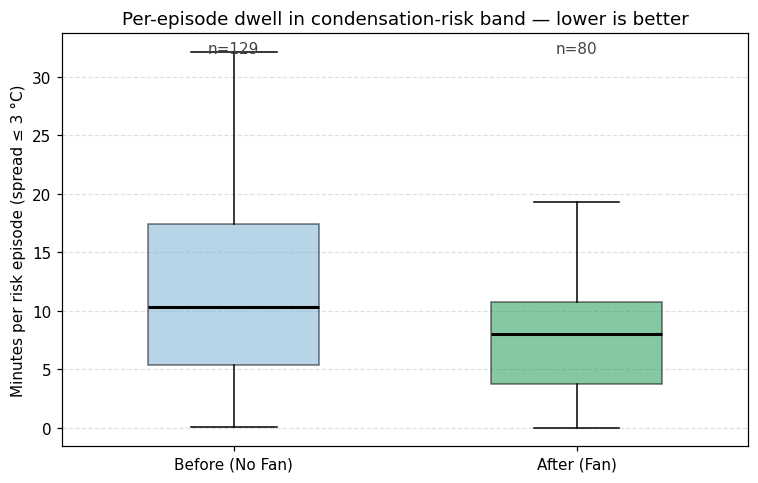

In [ ]:
order = ['Before (No Fan)', 'After (Fan)']
colors = ['#7fb3d5', '#239b56']
fig, ax = plt.subplots(figsize=(7, 4.5))
data = [epi[epi['Period'] == p]['dwell_min'] for p in order]
bp = ax.boxplot(data, tick_labels=order, patch_artist=True, showfliers=False, widths=0.5)
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor(col); patch.set_alpha(0.55)
for med in bp['medians']:
    med.set_color('black'); med.set_linewidth(2)
for j, p in enumerate(order):
    n = len(epi[epi['Period'] == p])
    ax.text(j + 1, ax.get_ylim()[1] * 0.95, f'n={n}', ha='center', fontsize=10, color='#444')
ax.set_ylabel('Minutes per risk episode (spread ≤ 3 °C)')
ax.set_title('Per-episode dwell in condensation-risk band — lower is better')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

Before (No Fan)   44.20
After (Fan)       32.30
Name: min/day in risk band, dtype: float64


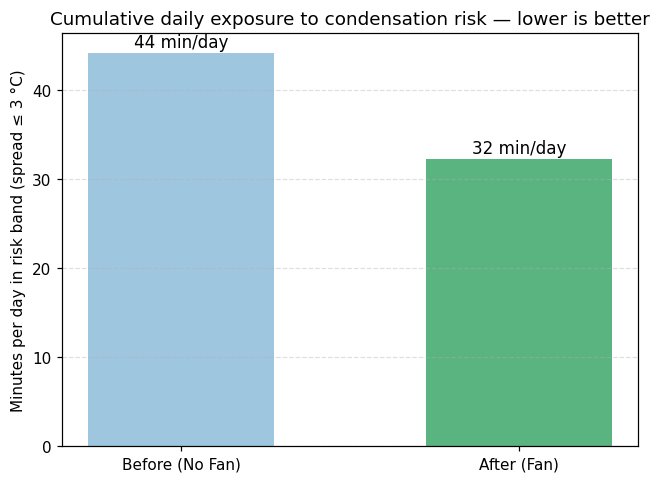

In [26]:
# Daily exposure: duration-weighted minutes in the risk band, normalised per day.
df['dur'] = df['ts'].shift(-1) - df['ts']
df.loc[df['dur'] > pd.Timedelta(minutes=30), 'dur'] = pd.NaT   # ignore sensor gaps

exposure = {}
for p, mask in [('Before (No Fan)', df['ts'] < SPLIT), ('After (Fan)', df['ts'] >= SPLIT)]:
    s = df[mask]
    risk_min = s[s['risk']]['dur'].sum().total_seconds() / 60
    days = (s['ts'].max() - s['ts'].min()).total_seconds() / 86400
    exposure[p] = risk_min / days

exp_tbl = pd.Series(exposure).round(1).rename('min/day in risk band')
print(exp_tbl.loc[order])

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(order, [exposure[p] for p in order], color=colors, alpha=0.75, width=0.55)
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.6,
            f'{b.get_height():.0f} min/day', ha='center', fontsize=11)
ax.set_ylabel('Minutes per day in risk band (spread ≤ 3 °C)')
ax.set_title('Cumulative daily exposure to condensation risk — lower is better')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

### Matched-window comparison (±20 days, equal length)

The min/day figure above normalises for unequal window lengths. For a headline before/after claim it's cleaner to compare **equal-length windows**: the 20 days before fan introduction vs the 20 days after. This removes the "Before period is longer" objection entirely — both are exactly 20 days.

A note on why dewpoint spread (not RH) is the right metric here: RH falls automatically when temperature rises, so a warmer *After* period would look drier on RH alone — a seasonal artefact. Spread (T − dewpoint) tracks the physical condensation margin instead. The dewpoint decomposition below confirms the *After* window was actually **more humid in absolute terms** (dewpoint +0.95 °C), so any reduction in risk exposure occurs *against* an adverse moisture drift, not because of it.

                 risk_minutes  risk_hours  dewpoint_°C  spread_°C
Period                                                           
Before (No Fan)           820       13.70        16.09       7.47
After (Fan)               645       10.70        17.04       7.59

Reduction: 820 -> 645 min  (175 min, 21% less time in condensation-risk band)


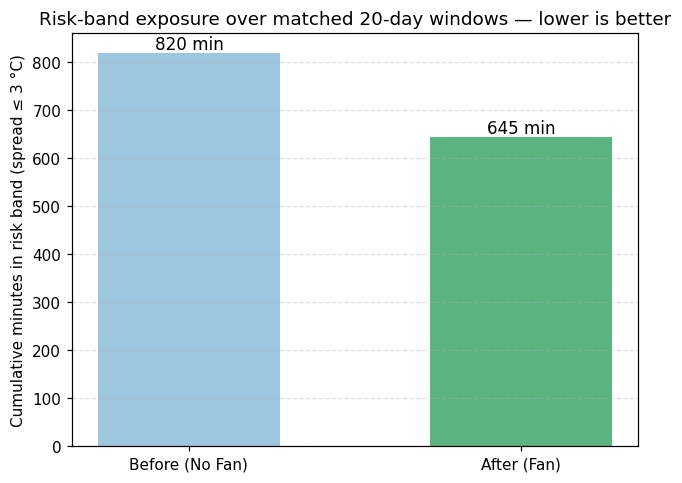

In [27]:
W20_LO = SPLIT - pd.Timedelta(days=20)
W20_HI = SPLIT + pd.Timedelta(days=20)
w20 = df[(df['ts'] >= W20_LO) & (df['ts'] < W20_HI)].sort_values('ts').copy()

w20['dur'] = w20['ts'].shift(-1) - w20['ts']
w20.loc[w20['dur'] > pd.Timedelta(minutes=30), 'dur'] = pd.NaT   # ignore sensor outages
w20['risk'] = w20['spread'] <= 3

rows = []
for lab, mask in [('Before (No Fan)', w20['ts'] < SPLIT), ('After (Fan)', w20['ts'] >= SPLIT)]:
    s = w20[mask]
    risk_min = s[s['risk']]['dur'].sum().total_seconds() / 60
    rows.append({'Period': lab, 'risk_minutes': round(risk_min),
                 'risk_hours': round(risk_min / 60, 1),
                 'dewpoint_°C': round(s['dewpoint'].mean(), 2),
                 'spread_°C': round(s['spread'].mean(), 2)})
cmp20 = pd.DataFrame(rows).set_index('Period').loc[['Before (No Fan)', 'After (Fan)']]
print(cmp20)

b = cmp20.loc['Before (No Fan)', 'risk_minutes']
af = cmp20.loc['After (Fan)', 'risk_minutes']
print(f"\nReduction: {b} -> {af} min  ({b-af} min, {100*(b-af)/b:.0f}% less time in condensation-risk band)")

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(['Before (No Fan)', 'After (Fan)'], [b, af], color=colors, alpha=0.75, width=0.55)
for rect in bars:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height()+8,
            f'{int(rect.get_height())} min', ha='center', fontsize=11)
ax.set_ylabel('Cumulative minutes in risk band (spread ≤ 3 °C)')
ax.set_title('Risk-band exposure over matched 20-day windows — lower is better')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

## 4. Measurement B — descent time from a humidity peak

For each high-humidity episode (contiguous RH ≥ 60%) whose peak reaches **≥ 90%** (a genuine shower-type spike), measure minutes from the peak down to the first crossing of 80 / 70 / 60% RH. This captures *transient recovery speed* — distinct from a dehumidifier's steady-state removal capacity.

In [28]:
df['hi'] = df['humidity'] >= 60
df['ev'] = (df['hi'] != df['hi'].shift()).cumsum()

rows = []
for _, g in df[df['hi']].groupby('ev'):
    if len(g) < 3:
        continue
    peak_val = g['humidity'].max()
    peak_t   = g.loc[g['humidity'].idxmax(), 'ts']
    if peak_val < 90:
        continue
    after = g[g['ts'] >= peak_t].sort_values('ts')
    p = period(peak_t)
    for thr, lab in [(80, 'to 80%'), (70, 'to 70%'), (60, 'to 60%')]:
        hit = after[after['humidity'] <= thr]
        if not hit.empty:
            rows.append({'Period': p, 'Target': lab,
                         'minutes': (hit['ts'].iloc[0] - peak_t).total_seconds() / 60})

desc = pd.DataFrame(rows)
desc.groupby(['Target','Period'])['minutes'].agg(['count','mean','median']).round(1)

count  mean  median
Target Period                              
to 60% After (Fan)          8 28.10   18.20
       Before (No Fan)     16 36.00   33.00
to 70% After (Fan)         45 10.70    8.60
       Before (No Fan)     85 18.00   14.70
to 80% After (Fan)         45  7.00    5.30
       Before (No Fan)     85 11.50    9.50

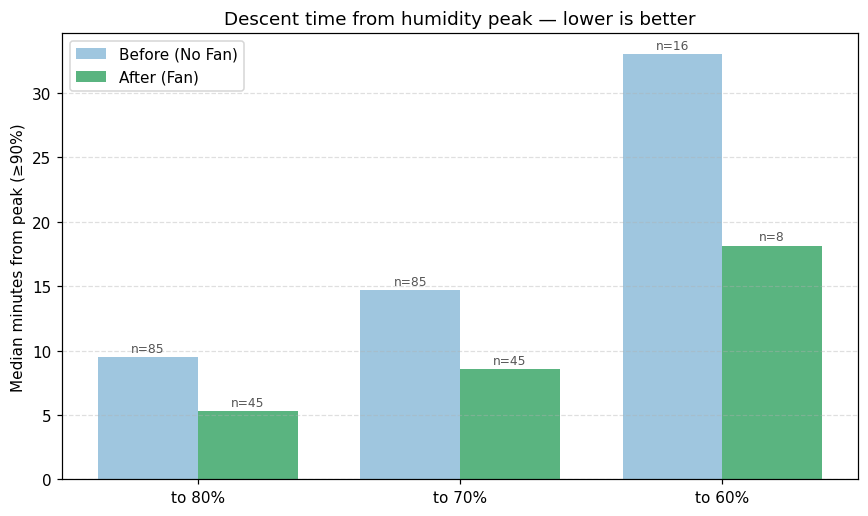

In [29]:
targets = ['to 80%', 'to 70%', 'to 60%']
x = np.arange(len(targets)); w = 0.38
fig, ax = plt.subplots(figsize=(8,4.8))
for k, (p, col) in enumerate(zip(order, colors)):
    meds, ns = [], []
    for tg in targets:
        sub = desc[(desc['Period']==p) & (desc['Target']==tg)]['minutes']
        meds.append(sub.median() if len(sub) else 0)
        ns.append(len(sub))
    bars = ax.bar(x + (k-0.5)*w, meds, w, label=p, color=col, alpha=0.75)
    for b, n in zip(bars, ns):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.4, f'n={n}',
                ha='center', fontsize=8, color='#555')
ax.set_xticks(x); ax.set_xticklabels(targets)
ax.set_ylabel('Median minutes from peak (≥90%)')
ax.set_title('Descent time from humidity peak — lower is better')
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

## 5. Average dewpoint-spread trajectory around risk touches

Centre each risk touch (spread ≤ 3 first reached) at t = 0 and average the ±60 min trajectory, split by period. The shaded band is the condensation-risk zone; a steeper climb out of it after t = 0 means faster recovery.

> **This plot is a trajectory, not a dwell-time measure.** Because it averages many episodes aligned at t = 0, the width of the curve inside the red band does **not** equal how long the flat actually spends at risk — averaging washes out individual episode lengths. For dwell time and cumulative exposure, read Section 3 (per-episode median and min/day), not the horizontal width here.

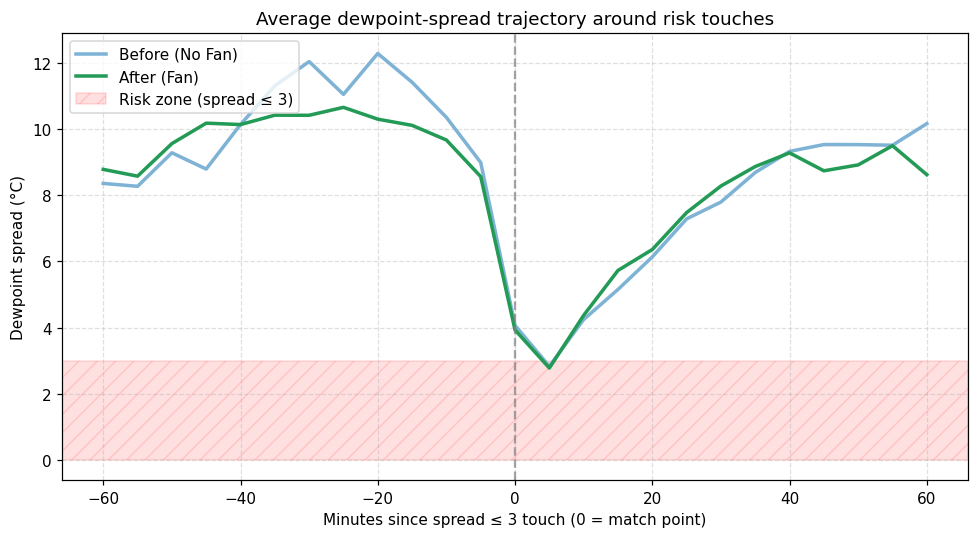

In [30]:
WIN = 60
frames = []
last_end = pd.Timestamp('2000-01-01', tz='Europe/London')
for i in df[df['risk']].index:
    t = df.loc[i, 'ts']
    if t <= last_end:
        continue
    frag = df[(df['ts'] >= t - pd.Timedelta(minutes=WIN)) &
              (df['ts'] <= t + pd.Timedelta(minutes=WIN))].copy()
    if frag.empty:
        continue
    frag['elapsed_min'] = (frag['ts'] - t).dt.total_seconds() / 60
    frag['Period'] = period(t)
    frames.append(frag[['elapsed_min','spread','Period']])
    last_end = t + pd.Timedelta(minutes=WIN)

traj = pd.concat(frames, ignore_index=True)
traj['bin'] = (traj['elapsed_min'] / 5).round() * 5   # 5-min bins

fig, ax = plt.subplots(figsize=(9,5))
for p, col in zip(order, colors):
    grp = traj[traj['Period']==p].groupby('bin')['spread'].agg(['mean','count'])
    grp = grp[grp['count'] >= 3]
    ax.plot(grp.index, grp['mean'], color=col, lw=2.3, label=p)
ax.axhspan(0, 3, color='red', alpha=0.12, hatch='//', label='Risk zone (spread ≤ 3)')
ax.axvline(0, color='grey', ls='--', alpha=0.7)
ax.set_xlabel('Minutes since spread ≤ 3 touch (0 = match point)')
ax.set_ylabel('Dewpoint spread (°C)')
ax.set_title('Average dewpoint-spread trajectory around risk touches')
ax.legend(loc='upper left'); ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout(); plt.show()

## 6. Findings

1. **Confound check passes.** Mean RH (≈64%) and mean dewpoint spread (≈7.6 °C) are near-identical across periods. The *After* period is ~1 °C warmer with marginally higher baseline humidity, so any improvement occurs *despite* a mildly adverse drift — strengthening the fan attribution.

2. **Per-episode dwell in the risk band is shorter with the fan:** median ≈10.3 → 8.0 min (n = 129 vs 80). Each individual visit to spread ≤ 3 clears a little faster.

3. **Cumulative daily exposure drops ~27%:** ≈44 → 32 min/day in the risk band. On a matched 20-day window the absolute figures are **820 → 645 min (−175 min, ~21% less)** time in the condensation-risk band — and the dewpoint decomposition shows the *After* window was absolutely more humid (dewpoint +0.95 °C), so the reduction runs against, not with, the seasonal drift. This is the mould-relevant headline — mould responds to total time at the condensation threshold, not the length of any single visit. It also matches the intuition read off the trajectory plot (the *Before* curve sits in the red band noticeably more across the day).

4. **Peak descent is faster at every threshold.** Largest gain is the early drop (peak → 70%), roughly halving in median time (≈14.7 → 8.6 min, n = 85 vs 45). The → 60% comparison agrees directionally but rests on small n (16 vs 8) — suggestive only.

**Why the trajectory plot looked inconsistent with the dwell numbers.** The Section-5 curve averages episodes aligned at t = 0, so the width of the averaged dip inside the red band is *not* a dwell time — it's where the mean trajectory happens to fall below 3 °C. Per-episode dwell and daily exposure (Section 3) are the correct quantities for "how long at risk".

**Reconciliation with the device-level (ON-event Δ) analysis.** A separate analysis aligned on dehumidifier/fan ON events found the dehumidifier removes more absolute moisture per hour (steady-state capacity), while the fan produces the larger *immediate* peak knock-down and faster risk-band clearing. Not contradictory — different questions: removal capacity vs recovery speed.

**Operational implication.** Manual operation only covers waking hours, while exposure accumulates overnight. A trigger such as *RH ≥ 65% → dehumidifier ON, with fan for circulation* would extend coverage into the hours the current manual routine misses.

**Limitations.** Single-flat data — descriptive only, no causal claim. *Before* window is longer (35 d vs 20 d); per-episode counts and daily-normalised exposure both account for this, but raw totals would not. Fan/dehumidifier ON-state is not labelled within each recovery episode here; the natural-experiment split assumes consistent window/dehumidifier behaviour across periods. A v3 step would label each episode with actual device ON/OFF state to remove residual confounding (intervention axis instead of calendar axis).